# Лабораторная 2
## Методы градиентного спуска
### Задачи
1) График целевой функции (квадратичная, ф-я Розенброка, ф-я Химмельблау): в 3D (поверхность) и 2D (линии уровня)
2) Метод, точность eps, количество итераций, количество вычисленных значений функции и её градиента (в сумме), точка минимума
3) Топография целевой функции (линии уровня с точками x_k и стрелками от x_k к x_k+1, если много итераций, то  изображать не все точки (несколько первых и несколько последних со стрелками)).
   График |W_k| в зависимости от k (в обычной и log системе) (т.е. 2 графика)
### Контрольные вопросы
1) Постановка задачи
2) Знать методы
3) Сильные и слабые стороны методов

### График целевой функции

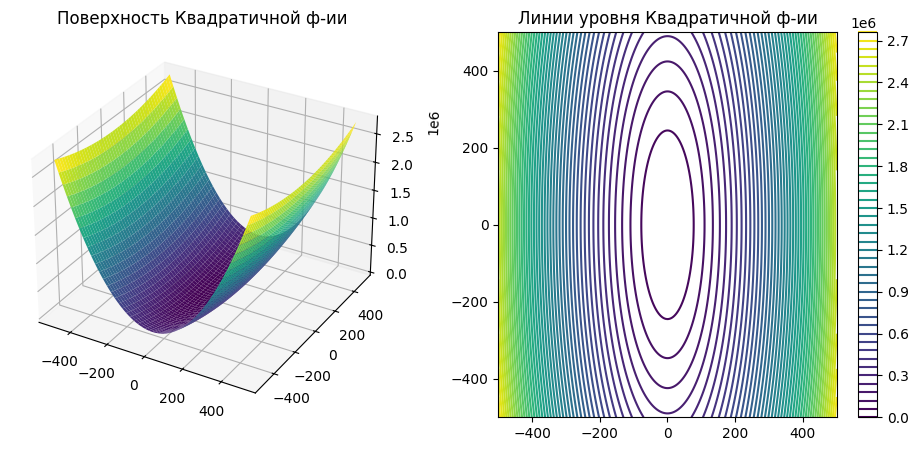

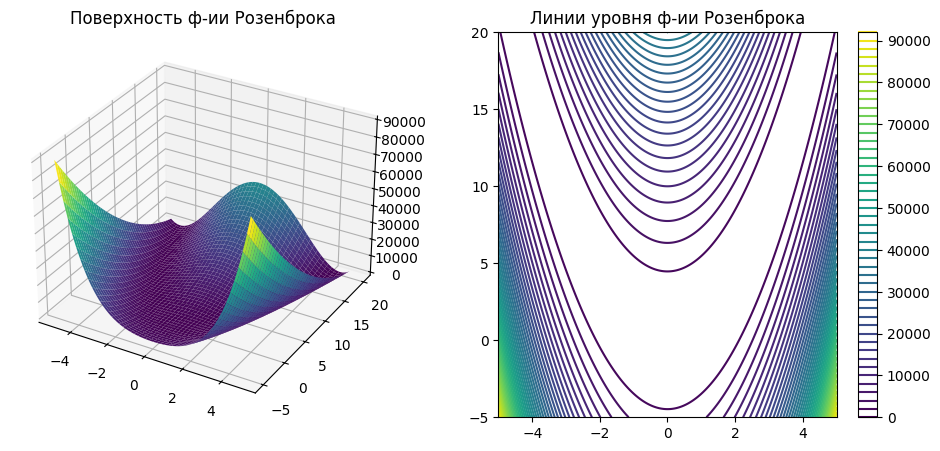

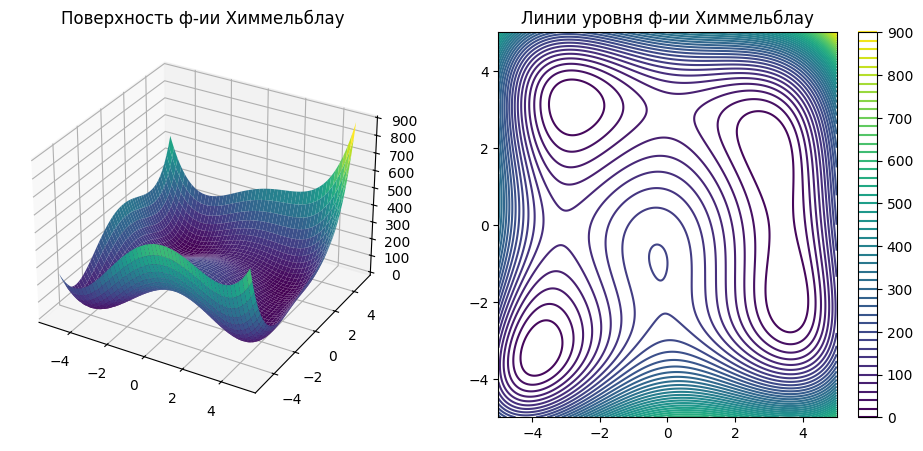

In [10]:
import numpy as np
import matplotlib.pyplot as plt

f_quad = lambda x, y: 10 * x**2 + y**2
f_rosen = lambda x, y: (1 - x)**2 + 100*(y - x**2)**2
f_himmel = lambda x, y: (x**2 + y - 11)**2 + (x + y**2 - 7)**2

functions = [
    ("Квадратичной ф-ии", f_quad, (-500, 500), (-500, 500)),
    ("ф-ии Розенброка", f_rosen, (-5, 5), (-5, 20)),
    ("ф-ии Химмельблау", f_himmel, (-5, 5), (-5, 5))
]

for name, func, x_segment, y_segment in functions:
    x = np.linspace(x_segment[0], x_segment[1], 400)
    y = np.linspace(y_segment[0], y_segment[1], 400)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)

    fig = plt.figure(figsize=(12,5))

    # 3D поверхность
    ax = fig.add_subplot(121, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_title("Поверхность " + name)


    # линии уровня
    ax2 = fig.add_subplot(122)
    contour = ax2.contour(X, Y, Z, levels=50)
    ax2.set_title("Линии уровня " + name)
    plt.colorbar(contour)

    plt.show()

### Метод наискорейшего спуска

In [15]:
import numpy as np
import math

def grad_quad(x, y):
    return np.array([20*x, 2*y])

def grad_rosen(x, y):
    dx = -2*(1-x) - 400*x*(y - x**2)
    dy = 200*(y - x**2)
    return np.array([dx, dy])

def grad_himmel(x, y):
    dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([dx, dy])


def golden_ratio(phi, a, b, x, anti_grad, eps=1e-6):
    t = (math.sqrt(5) - 1) / 2

    x1 = b - t*(b-a)
    x2 = a + t*(b-a)

    y1 = phi(x, x1, anti_grad)
    y2 = phi(x, x2, anti_grad)
    
    phi_calls = 2

    while abs(b-a) > eps:

        if y1 < y2:
            b = x2
            x2 = x1
            y2 = y1
            x1 = b - t*(b-a)
            y1 = phi(x, x1, anti_grad)

        else:
            a = x1
            x1 = x2
            y1 = y2
            x2 = a + t*(b-a)
            y2 = phi(x, x2, anti_grad)
        
        phi_calls += 1

    return (a+b)/2, phi_calls


def bracket_minimum(phi, x, anti_grad, step=0.01):
    a = 0
    b = step

    phi_calls = 0

    fa = phi(x, a, anti_grad)
    fb = phi(x, b, anti_grad)

    phi_calls += 2

    if fa < fb:
        return a, b, phi_calls

    while True:
        step *= 2
        c = b + step
        fc = phi(x, c, anti_grad)
        phi_calls += 1

        if fb < fc:
            return a, c, phi_calls

        a = b
        b = c
        fb = fc


def fastest_descent(func, func_grad, x0, eps=1e-4):

    x = np.array(x0, dtype=float)

    # одномерная функция
    phi = lambda x, a, anti_grad: func(x[0] + a*anti_grad[0], x[1] + a*anti_grad[1])

    points = [x.copy()]
    grad_norms = []

    iterations = 0
    func_grad_calls = 0

    grad = func_grad(x[0], x[1])
    func_grad_calls += 1
    grad_norms.append(np.linalg.norm(grad))

    while grad_norms[-1] > eps:

        anti_grad = -grad

        # ищем интервал
        a, b, phi_calls = bracket_minimum(phi, x, anti_grad)
        func_grad_calls += phi_calls

        # золотое сечение
        alpha, phi_calls = golden_ratio(phi, a, b, x, anti_grad)
        func_grad_calls += phi_calls

        # шаг к мининуму в сторону антиградиента
        x = x + alpha * anti_grad
        points.append(x.copy())

        grad = func_grad(x[0], x[1])
        grad_norms.append(np.linalg.norm(grad))

        iterations += 1
        func_grad_calls += 1

    return x, iterations, func_grad_calls, np.array(points), np.array(grad_norms)

functions = [
    ("Квадратичная", f_quad, grad_quad, [1, 5]),
    ("Розенробка", f_rosen, grad_rosen, [-1, 2]),
    ("Химмельблау", f_himmel, grad_himmel, [-2, 0])
]

gradient_descent_points = []

print("Метод наискорейшего спуска")
for name, func, grad, start in functions:

    minimum, iters, calls, points, grad_norms = fastest_descent(func, grad, start)
    gradient_descent_points.append([points, grad_norms])
    
    print()
    print("Функция:", name)
    print("Точка минимума:", minimum)
    print("Количество итераций:", iters)
    print("Количество вычислений функции и градиента:", calls)

Метод наискорейшего спуска

Функция: Квадратичная
Точка минимума: [-1.33587576e-06  2.67176571e-05]
Количество итераций: 43
Количество вычислений функции и градиента: 1462

Функция: Розенробка
Точка минимума: [0.99990956 0.99981889]
Количество итераций: 8228
Количество вычислений функции и градиента: 206387

Функция: Химмельблау
Точка минимума: [-2.80511769  3.13131342]
Количество итераций: 7
Количество вычислений функции и градиента: 208


### Метод градиентного спуска с дроблением шага

In [114]:
def gradient_descent_backtracking(f, grad_f, start, eps=1e-4):

    beta = 0.3
    alpha0 = 1

    x = np.array(start)

    points = [x.copy()]
    grad_norms = []
    
    iterations = 0
    count = 0

    g = grad_f(*x)
    count += 1
    grad_norms.append(np.linalg.norm(g))

    while grad_norms[-1] > eps:

        alpha = alpha0

        while f(*(x - alpha*g)) >= f(*x):
            alpha = beta * alpha
            count += 2
        else:
            count += 2

        x = x - alpha*g
        points.append(x.copy())

        g = grad_f(x[0], x[1])
        count += 1

        grad_norms.append(np.linalg.norm(g))

        iterations += 1

    return x, iterations, count, np.array(points), np.array(grad_norms)


functions = [
    ("Квадратичная", f_quad, grad_quad, [4,3]),
    ("Розенброка", f_rosen, grad_rosen, [-1,2]),
    ("Химмельблау", f_himmel, grad_himmel, [0,0])
]

gradient_descent_backtracking_points = []

print("Метод градиентного спуска с дроблением шага")
for name, f, grad, start in functions:

    minimum, iters, calls, points, grad_norms = gradient_descent_backtracking(f, grad, start)
    gradient_descent_backtracking_points.append([points, grad_norms])
    print()
    print("Функция:", name)
    print("Точка минимума:", minimum)
    print("Количество итераций:", iters)
    print("Количество вычислений функции и градиента:", calls)

Метод градиентного спуска с дроблением шага

Функция: Квадратичная
Точка минимума: [2.68435456e-05 2.01326592e-05]
Количество итераций: 13
Количество вычислений функции и градиента: 66

Функция: Розенброка
Точка минимума: [0.99990449 0.99980849]
Количество итераций: 8970
Количество вычислений функции и градиента: 119677

Функция: Химмельблау
Точка минимума: [2.99999831 2.00000195]
Количество итераций: 21
Количество вычислений функции и градиента: 212


### Топография квадратичной функции

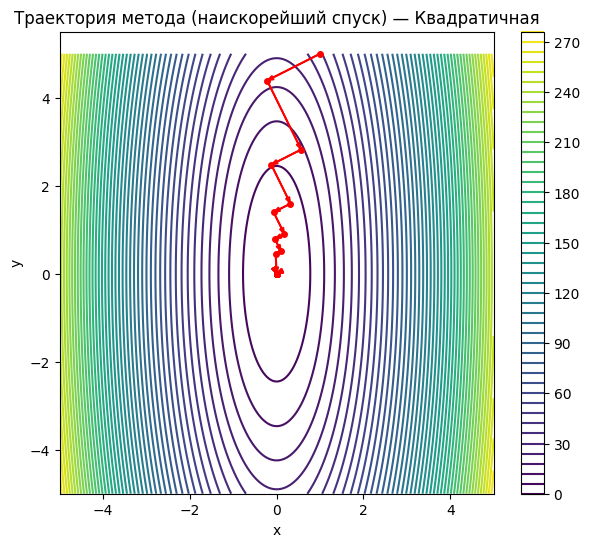

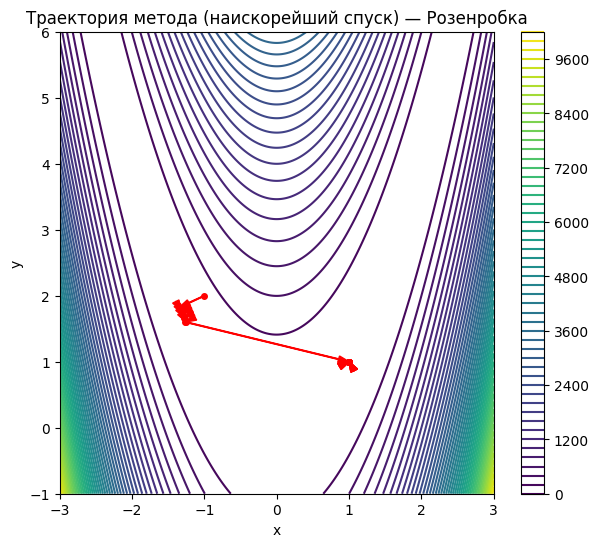

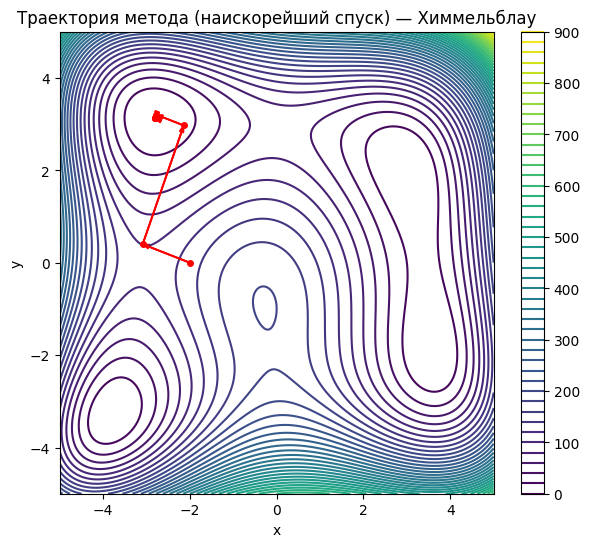

In [ ]:
import matplotlib.pyplot as plt

def plot_topography(func, points, x_range, y_range, title):

    x = np.linspace(x_range[0], x_range[1], 400)
    y = np.linspace(y_range[0], y_range[1], 400)

    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)

    plt.figure(figsize=(7,6))

    contour = plt.contour(X, Y, Z, levels=50)
    plt.colorbar(contour)

    # если итераций много — показываем только часть
    if len(points) > 40:
        idx = list(range(10)) + list(range(len(points)-10, len(points)))
        p = points[idx]
    else:
        p = points

    px = p[:,0]
    py = p[:,1]

    plt.plot(px, py, 'ro-', markersize=4)

    # стрелки
    for i in range(len(p)-1):
        dx = px[i+1] - px[i]
        dy = py[i+1] - py[i]

        plt.arrow(px[i], py[i], dx, dy,
                  head_width=0.1,
                  length_includes_head=True,
                  color='red')

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")

    plt.show()

ranges = [
    ((-5,5),(-5,5)),
    ((-3,3),(-1,6)),
    ((-5,5),(-5,5))
]

for i,(name,func,_,_) in enumerate(functions):

    points = gradient_descent_points[i][0]

    plot_topography(
        func,
        points,
        ranges[i][0],
        ranges[i][1],
        "Траектория метода (наискорейший спуск) — " + name
    )

#### Нормы градиента метода наискорейшего спуска

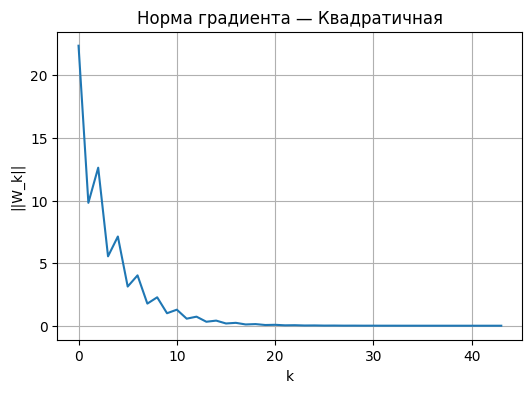

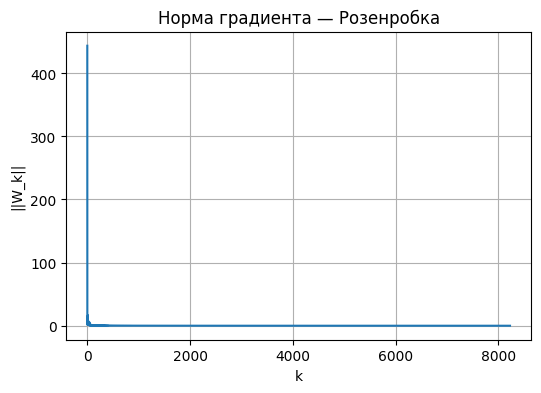

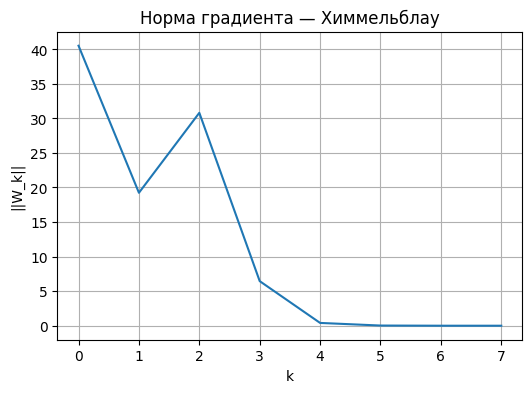

In [17]:
def plot_grad_norm(grad_norms, title):

    k = np.arange(len(grad_norms))

    plt.figure(figsize=(6,4))
    plt.plot(k, grad_norms)

    plt.xlabel("k")
    plt.ylabel("||W_k||")
    plt.title(title)

    plt.grid()
    plt.show()


for i,(name,_,_,_) in enumerate(functions):

    grad_norms = gradient_descent_points[i][1]

    plot_grad_norm(
        grad_norms,
        "Норма градиента — " + name
    )

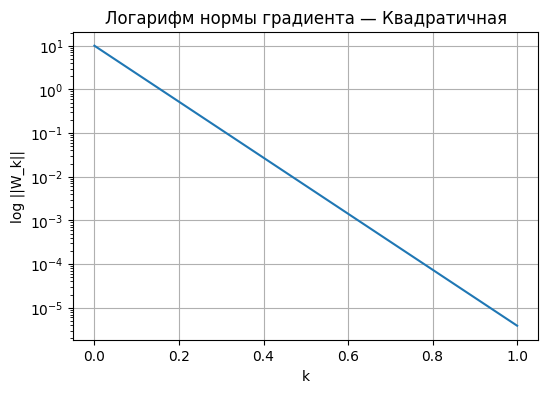

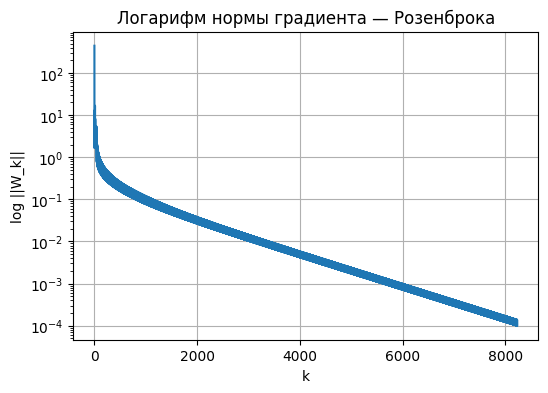

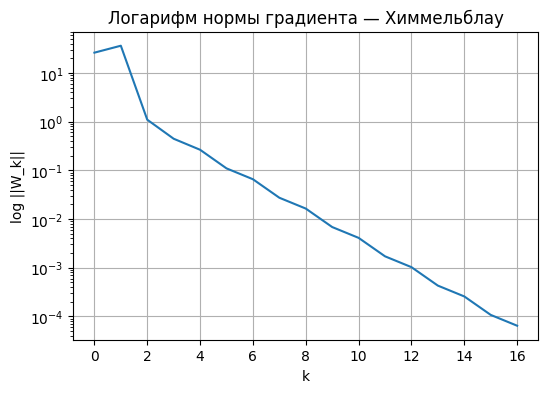

In [117]:
def plot_grad_norm_log(grad_norms, title):

    k = np.arange(len(grad_norms))

    plt.figure(figsize=(6,4))
    plt.semilogy(k, grad_norms)

    plt.xlabel("k")
    plt.ylabel("log ||W_k||")
    plt.title(title)

    plt.grid()
    plt.show()


for i,(name,_,_,_) in enumerate(functions):

    grad_norms = gradient_descent_points[i][1]

    plot_grad_norm_log(
        grad_norms,
        "Логарифм нормы градиента — " + name
    )

#### Нормы градиента метода с дроблением шага

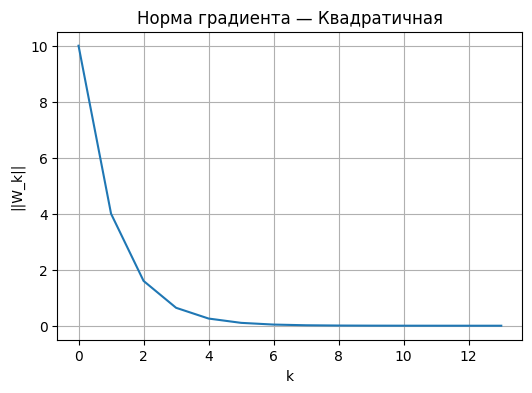

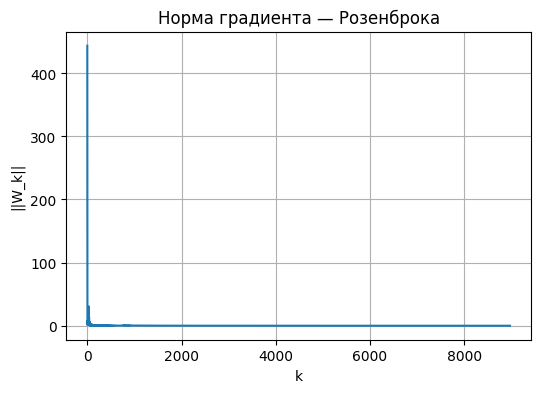

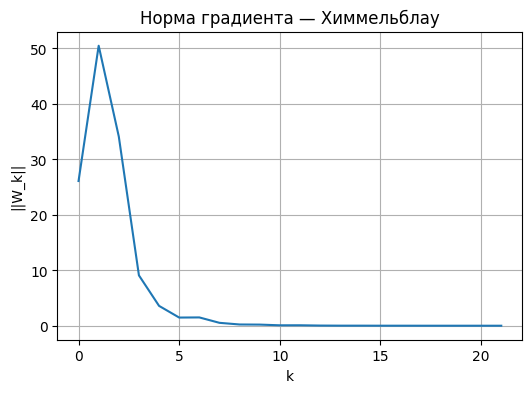

In [118]:
def plot_grad_norm(grad_norms, title):

    k = np.arange(len(grad_norms))

    plt.figure(figsize=(6,4))
    plt.plot(k, grad_norms)

    plt.xlabel("k")
    plt.ylabel("||W_k||")
    plt.title(title)

    plt.grid()
    plt.show()


for i,(name,_,_,_) in enumerate(functions):

    grad_norms = gradient_descent_backtracking_points[i][1]

    plot_grad_norm(
        grad_norms,
        "Норма градиента — " + name
    )

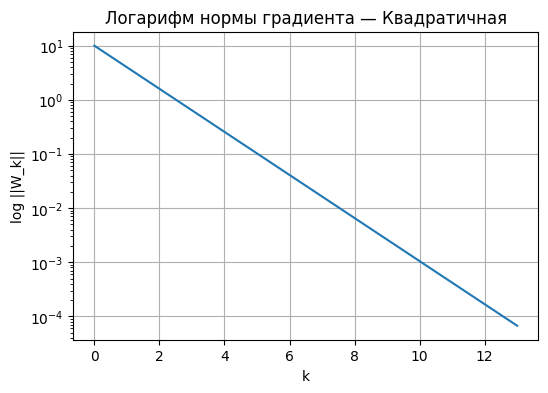

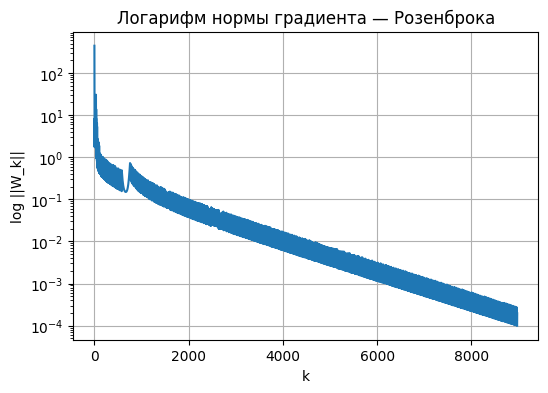

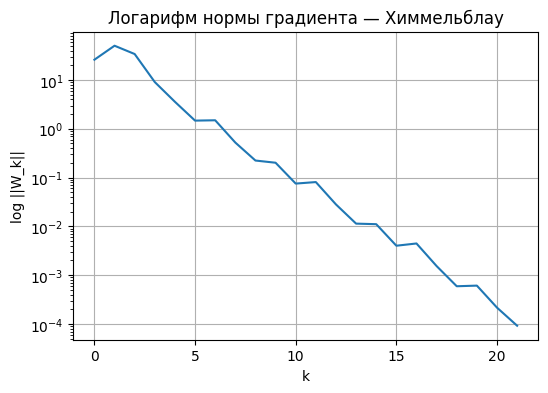

In [119]:
def plot_grad_norm_log(grad_norms, title):

    k = np.arange(len(grad_norms))

    plt.figure(figsize=(6,4))
    plt.semilogy(k, grad_norms)

    plt.xlabel("k")
    plt.ylabel("log ||W_k||")
    plt.title(title)

    plt.grid()
    plt.show()


for i,(name,_,_,_) in enumerate(functions):

    grad_norms = gradient_descent_backtracking_points[i][1]

    plot_grad_norm_log(
        grad_norms,
        "Логарифм нормы градиента — " + name
    )